<a href="https://colab.research.google.com/github/Thonyta17/Econ-5200/blob/main/Lab10/Correlation%2C_Causality%2C_and_Spurious_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from pandas_datareader import data as pdr


In [ ]:
#Date range (adjust as desired)
start = "2010-01-01"
end = "2024-12-31"

#FRED code -> clean column name
series = {
    "CPIAUCSL": "cpi",
    "UNRATE": "unrate",
    "FEDFUNDS": "fedfunds",
    "INDPRO": "indpro",
    "RSAFS": "retail_sales",
    "DGS10": "dgs10",
    "PAYEMS": "payrolls",
    "M2SL": "m2"
}

df_list = []
for fred_code, name in series.items():
    s = pdr.DataReader(fred_code, "fred", start, end)
    s.columns = [name]
    df_list.append(s)

df = pd.concat(df_list, axis=1 )

# Normalize to monthly start frequency (MS) and average within month for daily/irregular series
df = df. resample("MS"). mean ()
# Drop rows with any missing values to create a clean aligned sample
df = df.dropna().copy()

print("Shape:", df.shape)
print(df.head())
print(df.shape)

Shape: (180, 8)
                cpi  unrate  fedfunds   indpro  retail_sales     dgs10  \
DATE                                                                     
2010-01-01  217.488     9.8      0.11  89.3426      339093.0  3.733158   
2010-02-01  217.281     9.8      0.13  89.6779      339580.0  3.691053   
2010-03-01  217.353     9.9      0.16  90.2928      346974.0  3.727391   
2010-04-01  217.403     9.9      0.20  90.5991      349869.0  3.846818   
2010-05-01  217.290     9.6      0.20  91.8230      346858.0  3.420000   

            payrolls      m2  
DATE                          
2010-01-01  129802.0  8477.7  
2010-02-01  129706.0  8527.3  
2010-03-01  129866.0  8523.5  
2010-04-01  130120.0  8554.8  
2010-05-01  130642.0  8609.0  
(180, 8)


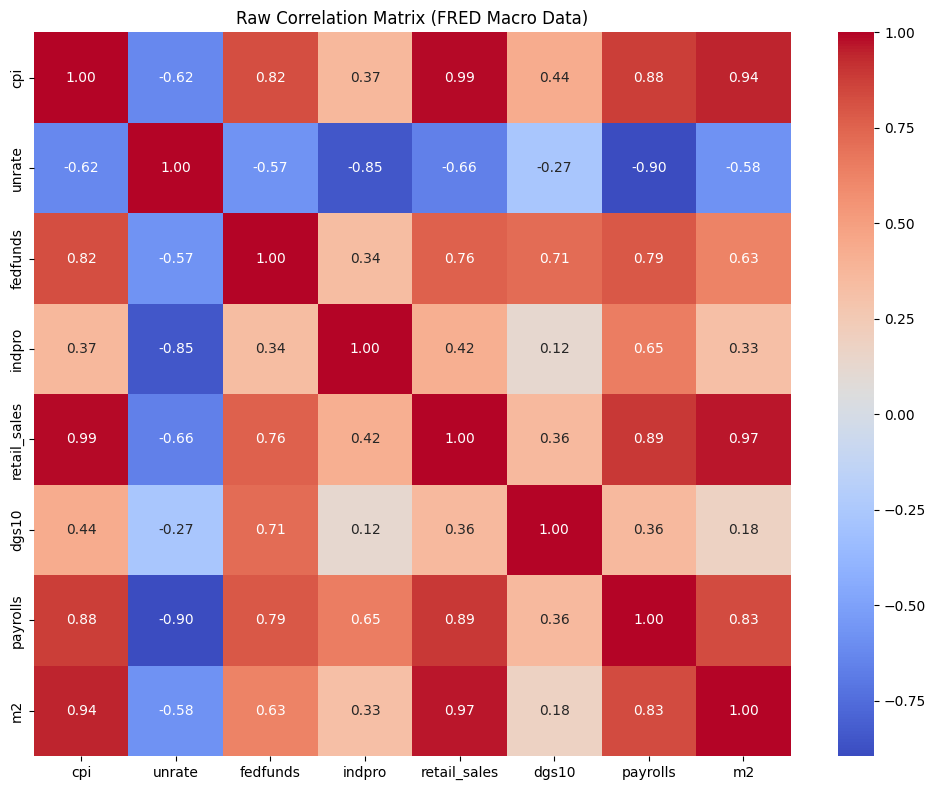

In [ ]:
plt.figure(figsize=(10, 8))

corr = df.corr()

sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Raw Correlation Matrix (FRED Macro Data)")
plt.tight_layout()
plt.show()